# FGSM Phase 2 — Variant Z: Ensemble Defenses via Detection-Level Merging

**Objective**: Test ENSEMBLE defenses — run inference on multiple separately-defended
versions of the attacked image, then merge the detections via NMS. Unlike Variants C/D
which chain defenses at the pixel level (information destruction compounds), Variant Z
lets each defense's strength be preserved and combines them at the detection-voting level.

**Hypothesis**: Detection-level ensembling should recover more mAP than either solo
defenses or sequential pixel-chains, because each branch sees an in-distribution
(individually denoised) image, and true objects survive across multiple defenses
while adversarial detections rarely do.

## 6 Solo Building Blocks (all GPU-accelerated where possible)
1. **JPEG** (q=75) — Dziugaite et al. 2016 — frequency/DCT squeezing — CPU
2. **Median Filter** (3×3) — Xu et al. NDSS 2018 — local spatial — GPU
3. **TVM** (w=0.05, 200 iter) — Guo et al. ICLR 2018 — variational — GPU
4. **Gaussian Blur** (σ=1.0) — Xu et al. NDSS 2018 — spatial low-pass — GPU
5. **SVD** (90% keep) — spectral low-rank — GPU
6. **Blur→TVM** — Variant C winner combo (+44.7% recovery) — GPU

## 5 Ensembles (offline NMS-merging of solo detection sets)
- **Z1 (top-3)**: JPEG + Median + TVM
- **Z2 (orthogonal)**: JPEG + TVM + SVD
- **Z3 (classical)**: JPEG + Median + Gaussian
- **Z4 (4-way)**: JPEG + Median + TVM + Gaussian
- **Z5 (blur_tvm combo)**: JPEG + Blur→TVM + Median

## Compute budget
- **Per-image inference calls**: 14 (1 clean + 6 clean+def + 1 attacked + 6 att+def)
- **Ensembles are FREE**: built offline by merging existing per-image solo detection JSONs
- **Hardware**: 2× A6000 via ThreadPoolExecutor, round-robin image split
- **Scale**: 1000 images, FGSM eps=0.03 only


## 1. Setup and Imports

In [16]:
import os
import json

# ============================================================
# GPU ISOLATION -- Must happen BEFORE import torch
# Set NUM_GPUS here. CUDA_VISIBLE_DEVICES must be set before
# PyTorch initializes CUDA, otherwise it has no effect.
# ============================================================
NUM_GPUS = 2        # <-- SET THIS: how many GPUs to use
GPU_POOL = [0,1]   # <-- SET THIS: which physical GPUs to choose from (e.g. [0,1,2,3] = all, [2,3] = only GPU 2&3)

# Pick the best GPU(s) by free memory from GPU_POOL only
import subprocess
try:
    smi = subprocess.run(
        ["nvidia-smi", "--query-gpu=index,memory.free",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True, timeout=10
    )
    gpu_free = []
    for line in smi.stdout.strip().split("\n"):
        idx, free = line.split(",")
        idx, free = int(idx.strip()), int(free.strip())
        if idx in GPU_POOL:
            gpu_free.append((idx, free))
    gpu_free.sort(key=lambda x: x[1], reverse=True)
    if len(gpu_free) < NUM_GPUS:
        print(f"WARNING: Only {len(gpu_free)} GPUs available in pool {GPU_POOL}, requested {NUM_GPUS}")
    selected = [str(g[0]) for g in gpu_free[:NUM_GPUS]]
    os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(selected)
    print(f"GPU isolation: pool={GPU_POOL}, NUM_GPUS={NUM_GPUS}")
    mem_info = [(g[0], f'{g[1]}MiB') for g in gpu_free]
    print(f"  Free memory: {mem_info}")
    print(f"  Selected physical GPU(s): {selected}")
    print(f"  CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")
except Exception as e:
    print(f"nvidia-smi query failed ({e}), using default CUDA_VISIBLE_DEVICES")

# Now safe to import torch -- it will only see the selected GPU(s)
import torch
import numpy as np
from PIL import Image, ImageFilter
from io import BytesIO
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModelForCausalLM
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision import transforms
import GPUtil
import time
import warnings
import gc
import matplotlib.pyplot as plt
import cv2
from skimage.restoration import denoise_tv_chambolle

warnings.filterwarnings("ignore")

# Verify GPU isolation
n_visible = torch.cuda.device_count()
print(f"PyTorch sees {n_visible} GPU(s) (requested {NUM_GPUS})")
assert n_visible <= NUM_GPUS, (
    f"Expected at most {NUM_GPUS} GPU(s) but {n_visible} visible. "
    f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')}"
)

# DiffPure REMOVED -- Nie et al. 2022 tested only on classification, not OD
# SmoothVLM REMOVED -- Sun et al. 2024 tested only on text generation, not OD

print("All core imports successful.")

GPU isolation: pool=[0, 1], NUM_GPUS=2
  Free memory: [(1, '46118MiB'), (0, '45076MiB')]
  Selected physical GPU(s): ['1', '0']
  CUDA_VISIBLE_DEVICES=1,0
PyTorch sees 2 GPU(s) (requested 2)
All core imports successful.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## 1.5 GPU Diagnostics & Device Selection
Print all available GPUs, their memory usage, and select the most free one.

In [17]:
# ============================================================
# GPU DIAGNOSTICS (GPU isolation already done in imports cell)
# ============================================================
print("=" * 70)
print(f"GPU DIAGNOSTICS (NUM_GPUS={NUM_GPUS})")
print("=" * 70)

import subprocess
try:
    result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    print(result.stdout)
except Exception as e:
    print(f"nvidia-smi failed: {e}")

print("-" * 70)
n_gpus = torch.cuda.device_count()
print(f"GPUs visible to PyTorch: {n_gpus}")

for i in range(n_gpus):
    free, total = torch.cuda.mem_get_info(i)
    props = torch.cuda.get_device_properties(i)
    used_pct = (total - free) / total * 100
    print(f"  GPU {i}: {props.name}")
    print(f"    Memory: {(total-free)/1024**2:.0f}MB used / {total/1024**2:.0f}MB total ({used_pct:.1f}% used)")
    print(f"    Free: {free/1024**3:.2f} GB")

device = torch.device("cuda:0")
torch_dtype = torch.float16

props = torch.cuda.get_device_properties(0)
free, total = torch.cuda.mem_get_info(0)
print(f"\n>> Primary device: {device} -> {props.name} ({free/1024**3:.2f} GB free)")
print(f"Device: {device}, Dtype: {torch_dtype}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print("=" * 70)


GPU DIAGNOSTICS (NUM_GPUS=2)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Sun Apr 12 21:54:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               Off |   00000000:3B:00.0 Off |                  Off |
| 30%   25C    P8             18W /  300W |    3594MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Configuration

In [18]:
# ============================================================
# CONFIGURATION — Variant Z: Ensemble Defenses
# ============================================================

# Dataset paths
IMAGE_DIR = "./val2017"
ANN_FILE = "./annotations/instances_val2017.json"

# Number of images
NUM_IMAGES = 1000

# FGSM epsilon (only strongest attack — 0.003/0.01 showed no recovery differentiation)
EPSILONS = [0.03]

# Component parameters (same proven values from Variants A & B)
JPEG_QUALITY = 75          # Dziugaite et al., 2016
MEDIAN_KERNEL = 3          # Xu et al., NDSS 2018
TVM_WEIGHT = 0.05          # Guo et al., ICLR 2018
TVM_ITERS = 200
GAUSSIAN_SIGMA = 1.0       # Xu et al., NDSS 2018
SVD_KEEP_RATIO = 0.90

# NMS
NMS_IOU_THRESHOLD = 0.5
ENSEMBLE_NMS_IOU = 0.5     # NMS IoU for merging across branches

# ---- SOLO DEFENSES (building blocks; each runs as an independent inference branch) ----
SOLO_DEFENSES = ["jpeg", "median", "tvm", "gaussian", "svd", "blur_tvm"]

# ---- ENSEMBLES (offline NMS-merge of solo detection sets) ----
ENSEMBLES = {
    "ens_jpeg_median_tvm":      ["jpeg", "median", "tvm"],
    "ens_jpeg_tvm_svd":         ["jpeg", "tvm", "svd"],
    "ens_jpeg_median_gaussian": ["jpeg", "median", "gaussian"],
    "ens_4way":                 ["jpeg", "median", "tvm", "gaussian"],
    "ens_blur_tvm_combo":       ["jpeg", "blur_tvm", "median"],
}

OUTPUT_DIR = "./results_phase2_variantZ"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Variant Z: Ensemble Defenses via Detection-Level NMS Merging")
print(f"  Images: {NUM_IMAGES},  Epsilon: {EPSILONS}")
print(f"  Solo building blocks ({len(SOLO_DEFENSES)}): {SOLO_DEFENSES}")
print(f"  Ensembles ({len(ENSEMBLES)}):")
for name, members in ENSEMBLES.items():
    print(f"    {name:<30s} = {' + '.join(members)}")


Variant Z: Ensemble Defenses via Detection-Level NMS Merging
  Images: 1000,  Epsilon: [0.03]
  Solo building blocks (6): ['jpeg', 'median', 'tvm', 'gaussian', 'svd', 'blur_tvm']
  Ensembles (5):
    ens_jpeg_median_tvm            = jpeg + median + tvm
    ens_jpeg_tvm_svd               = jpeg + tvm + svd
    ens_jpeg_median_gaussian       = jpeg + median + gaussian
    ens_4way                       = jpeg + median + tvm + gaussian
    ens_blur_tvm_combo             = jpeg + blur_tvm + median


## 3. Load Model and Dataset

In [19]:
# ============================================================
# Model Loading — replicated on ALL visible GPUs
# ============================================================
print(f"Using dtype: {torch_dtype}")

model_name = "microsoft/Florence-2-base"
revision = "refs/pr/26"

processor = AutoProcessor.from_pretrained(
    model_name, revision=revision, trust_remote_code=True
)

n_gpus = torch.cuda.device_count()
print(f"Loading Florence-2-Base on {n_gpus} GPU(s)...")

models = {}
img_means = {}
img_stds = {}

for gpu_idx in range(n_gpus):
    dev = torch.device(f'cuda:{gpu_idx}')
    m = AutoModelForCausalLM.from_pretrained(
        model_name, revision=revision,
        torch_dtype=torch_dtype, trust_remote_code=True
    ).to(dev).eval()
    models[gpu_idx] = m
    img_means[gpu_idx] = torch.tensor(
        processor.image_processor.image_mean, device=dev, dtype=torch_dtype
    ).view(1, 3, 1, 1)
    img_stds[gpu_idx] = torch.tensor(
        processor.image_processor.image_std, device=dev, dtype=torch_dtype
    ).view(1, 3, 1, 1)
    free, total = torch.cuda.mem_get_info(gpu_idx)
    print(f"  GPU {gpu_idx}: model loaded ({(total-free)/1024**2:.0f}MB / {total/1024**2:.0f}MB)")

# Backward-compatible globals (used by sanity checks, visualization, defenses)
model = models[0]
device = torch.device('cuda:0')
IMG_MEAN = img_means[0]
IMG_STD = img_stds[0]

coco_gt = COCO(ANN_FILE)
categories = coco_gt.loadCats(coco_gt.getCatIds())
category_mapping = {c["name"]: c["id"] for c in categories}
print(f"COCO categories loaded: {len(category_mapping)}")

files = sorted(os.listdir(IMAGE_DIR))
if NUM_IMAGES is not None:
    files = files[:NUM_IMAGES]
evaluated_img_ids = sorted([int(os.path.splitext(f)[0]) for f in files])
print(f"Will process {len(files)} images (img_ids tracked for COCOeval).")

Using dtype: torch.float16
Loading Florence-2-Base on 2 GPU(s)...
  GPU 0: model loaded (3594MB / 48670MB)
  GPU 1: model loaded (2552MB / 48670MB)
loading annotations into memory...
Done (t=0.82s)
creating index...
index created!
COCO categories loaded: 80
Will process 1000 images (img_ids tracked for COCOeval).


## 4. Core Utilities: NMS and Inference

In [20]:
# ============================================================
# Florence-2 -> COCO Label Mapping
# Florence-2 outputs many labels that don't match COCO names.
# Without this mapping, ~55% of detections are silently dropped.
# ============================================================

FLORENCE_TO_COCO = {
    # Persons
    "man": "person", "woman": "person", "boy": "person", "girl": "person",
    "child": "person", "baby": "person", "kid": "person", "player": "person",
    "pedestrian": "person", "human": "person", "skier": "person",
    "snowboarder": "person", "surfer": "person", "rider": "person",
    # Vehicles
    "automobile": "car", "van": "car", "sedan": "car", "suv": "car",
    "taxi": "car", "minivan": "car",
    "motor bike": "motorcycle", "motorbike": "motorcycle",
    "aeroplane": "airplane", "aircraft": "airplane", "jet": "airplane",
    "lorry": "truck", "pickup truck": "truck",
    # Electronics
    "television": "tv", "tv set": "tv", "monitor": "tv", "screen": "tv",
    "television set": "tv",
    "mobile phone": "cell phone", "cellphone": "cell phone",
    "smartphone": "cell phone", "phone": "cell phone",
    "computer keyboard": "keyboard",
    "computer mouse": "mouse",
    "notebook computer": "laptop", "notebook": "laptop",
    # Furniture
    "studio couch": "couch", "sofa": "couch", "settee": "couch",
    "kitchen & dining room table": "dining table", "table": "dining table",
    "desk": "dining table",
    "swivel chair": "chair", "armchair": "chair", "stool": "chair",
    # Animals
    "puppy": "dog", "kitten": "cat",
    # Sports
    "ski": "skis", "ski pole": "skis",
    "racket": "tennis racket",
    "ball": "sports ball", "football": "sports ball",
    "soccer ball": "sports ball", "baseball": "sports ball",
    "basketball": "sports ball", "tennis ball": "sports ball",
    # Objects
    "glove": "baseball glove",
    "houseplant": "potted plant", "plant": "potted plant", "flower pot": "potted plant",
    "flowerpot": "potted plant",
    "wine bottle": "bottle", "beer bottle": "bottle", "water bottle": "bottle",
    "drinking glass": "wine glass", "glass": "wine glass", "goblet": "wine glass",
    "pocketknife": "knife", "kitchen knife": "knife", "butter knife": "knife",
    "hair dryer": "hair drier", "hairdryer": "hair drier", "blow dryer": "hair drier",
    "wristwatch": "clock", "wall clock": "clock", "alarm clock": "clock",
    "bag": "handbag", "purse": "handbag", "wristlet": "handbag",
    "briefcase": "suitcase", "luggage": "suitcase", "travel bag": "suitcase",
    "backpack bag": "backpack",
    "traffic signal": "traffic light",
    "fire plug": "fire hydrant",
}


def _map_label(label):
    """Map Florence-2 label to COCO name. Try exact match first, then mapping."""
    if label in category_mapping:
        return label
    mapped = FLORENCE_TO_COCO.get(label)
    if mapped and mapped in category_mapping:
        return mapped
    lower = label.lower()
    if lower in category_mapping:
        return lower
    mapped_lower = FLORENCE_TO_COCO.get(lower)
    if mapped_lower and mapped_lower in category_mapping:
        return mapped_lower
    return None


def _compute_score(box, img_w, img_h):
    """
    Heuristic confidence score based on box geometry.
    COCO mAP needs varying scores for meaningful precision-recall curves.
    Applied identically to ALL conditions (clean, attacked, defended) for fairness.
    """
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    img_area = img_w * img_h
    box_area = w * h
    area_ratio = min(box_area / img_area, 0.5) if img_area > 0 else 0
    box_cx, box_cy = (x1 + x2) / 2, (y1 + y2) / 2
    img_cx, img_cy = img_w / 2, img_h / 2
    center_dist = np.sqrt(((box_cx - img_cx) / img_w) ** 2 +
                          ((box_cy - img_cy) / img_h) ** 2)
    score = 0.6 + 0.2 * area_ratio + 0.15 * (1 - center_dist)
    return min(0.98, max(0.6, score))


# ============================================================
# NMS
# ============================================================

def box_iou(a, b):
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0


def non_max_suppression(boxes, labels, scores, iou_thr=0.5):
    if not boxes:
        return [], [], []
    boxes = np.array(boxes)
    idxs = np.argsort(scores)[::-1]
    keep, keep_labels, keep_scores = [], [], []
    for i in idxs:
        suppress = False
        for j in keep:
            if labels[i] == labels[j] and box_iou(boxes[i], boxes[j]) > iou_thr:
                suppress = True
                break
        if not suppress:
            keep.append(i)
            keep_labels.append(labels[i])
            keep_scores.append(scores[i])
    return boxes[keep].tolist(), keep_labels, keep_scores


# ============================================================
# Inference (universal for all conditions)
# ============================================================

def run_inference(pil_img):
    """Run Florence-2 OD with label mapping and heuristic scores."""
    img_w, img_h = pil_img.size
    with torch.no_grad():
        inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
        input_ids = inputs.input_ids.to(device)
        pixel_values = inputs.pixel_values.to(device=device, dtype=torch_dtype)
        gen_ids = model.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
        txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(img_w, img_h)
        ) or {}

    od = parsed.get("<OD>", {})
    bboxes, labels = od.get("bboxes", []), od.get("labels", [])
    scores = [_compute_score(box, img_w, img_h) for box in bboxes]
    kept_boxes, kept_labels, kept_scores = non_max_suppression(
        bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
    )
    results = []
    for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
        mapped = _map_label(label)
        if mapped is None:
            continue
        cid = category_mapping[mapped]
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        if w <= 0 or h <= 0:
            continue
        results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
    return results

print("Inference pipeline ready (with label mapping + heuristic scores).")

# ============================================================
# Batched Inference (processes multiple images in one generate call)
# ============================================================

def run_inference_batch(pil_imgs, gpu_idx=0):
    """Run Florence-2 OD on a batch of images. Returns list of results per image."""
    if not pil_imgs:
        return []

    dev = torch.device(f'cuda:{gpu_idx}')
    mdl = models[gpu_idx]
    img_sizes = [img.size for img in pil_imgs]  # (w, h) per image

    with torch.no_grad():
        texts = ["<OD>"] * len(pil_imgs)
        inputs = processor(text=texts, images=pil_imgs, return_tensors="pt", padding=True)
        input_ids = inputs.input_ids.to(dev)
        pixel_values = inputs.pixel_values.to(device=dev, dtype=torch_dtype)
        attention_mask = inputs.get("attention_mask")
        if attention_mask is not None:
            attention_mask = attention_mask.to(dev)

        gen_kwargs = dict(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
        if attention_mask is not None:
            gen_kwargs["attention_mask"] = attention_mask

        gen_ids = mdl.generate(**gen_kwargs)
        texts_out = processor.batch_decode(gen_ids, skip_special_tokens=False)

    batch_results = []
    for txt, (img_w, img_h) in zip(texts_out, img_sizes):
        parsed = processor.post_process_generation(
            txt, task="<OD>", image_size=(img_w, img_h)
        ) or {}

        od = parsed.get("<OD>", {})
        bboxes, labels = od.get("bboxes", []), od.get("labels", [])
        scores = [_compute_score(box, img_w, img_h) for box in bboxes]
        kept_boxes, kept_labels, kept_scores = non_max_suppression(
            bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
        )
        results = []
        for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
            mapped = _map_label(label)
            if mapped is None:
                continue
            cid = category_mapping[mapped]
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0:
                continue
            results.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
        batch_results.append(results)

    return batch_results

print("Batched inference pipeline ready (per-image flow uses run_inference instead).")


Inference pipeline ready (with label mapping + heuristic scores).
Batched inference pipeline ready (per-image flow uses run_inference instead).


## 5. FGSM Attack
Reference: Goodfellow et al., "Explaining and Harnessing Adversarial Examples," ICLR 2015.

In [21]:
def fgsm_attack(pil_img, eps=0.01, gpu_idx=0):
    """Per-GPU FGSM attack on a single image."""
    dev = torch.device(f'cuda:{gpu_idx}')
    mdl = models[gpu_idx]
    mean = img_means[gpu_idx].squeeze(0)
    std = img_stds[gpu_idx].squeeze(0)

    orig_size = pil_img.size
    inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
    input_ids = inputs.input_ids.to(dev)
    pixel_values = inputs.pixel_values.to(device=dev, dtype=torch_dtype)

    with torch.no_grad():
        target_ids = mdl.generate(
            input_ids=input_ids, pixel_values=pixel_values,
            max_new_tokens=512, num_beams=5, do_sample=False,
            repetition_penalty=1.8, length_penalty=1.0,
        )
    target_ids = target_ids[:1, :].contiguous()
    if target_ids.size(1) > 512:
        target_ids = target_ids[:, :512].contiguous()

    pixel_values_adv = pixel_values.clone().detach().requires_grad_(True)
    outputs = mdl(input_ids=input_ids, pixel_values=pixel_values_adv, labels=target_ids)
    outputs.loss.backward()

    grad_sign = pixel_values_adv.grad.sign()
    adv_pixel_values = pixel_values.detach() + eps * grad_sign
    adv_pixel_values = torch.clamp(adv_pixel_values, -2.5, 2.5)

    adv_denorm = adv_pixel_values.squeeze(0) * std + mean
    adv_denorm = torch.clamp(adv_denorm, 0.0, 1.0)
    adv_np = (adv_denorm.permute(1, 2, 0).cpu().float().numpy() * 255).astype(np.uint8)
    adv_pil = Image.fromarray(adv_np)
    if adv_pil.size != orig_size:
        adv_pil = adv_pil.resize(orig_size, Image.BICUBIC)
    return adv_pil

print("FGSM attack function ready (per-GPU, single image).")


FGSM attack function ready (per-GPU, single image).


## 6. Defense Functions — Variant Z: 6 Solo Building Blocks (GPU where possible)

All solo defenses run independently on attacked images. Each produces its own PIL image
that gets fed into a separate Florence-2 inference. Detection-level ensembles are then
merged offline via NMS — zero additional inference.


In [22]:
# ============================================================
# GPU-accelerated defense building blocks
# JPEG is CPU (very fast). Everything else on GPU.
# ============================================================

# --- PIL <-> GPU tensor helpers ---
def pil_to_tensor(pil_img, gpu_idx=0):
    dev = torch.device(f'cuda:{gpu_idx}')
    arr = np.array(pil_img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(dev)

def tensor_to_pil(t):
    arr = (t.squeeze(0).clamp(0, 1) * 255).byte().permute(1, 2, 0).cpu().numpy()
    return Image.fromarray(arr)

# --- GPU TVM (Chambolle 2004) ---
@torch.no_grad()
def tvm_gpu(tensors, weight=TVM_WEIGHT, n_iter=TVM_ITERS):
    N, C, H, W = tensors.shape
    x = tensors.reshape(N * C, H, W)
    p = torch.zeros(N * C, 2, H, W, device=x.device, dtype=x.dtype)
    tau = 0.25
    for _ in range(n_iter):
        d = -(p[:, 0] + p[:, 1])
        d[:, 1:, :] += p[:, 0, :-1, :]
        d[:, :, 1:] += p[:, 1, :, :-1]
        out = x + d
        g = torch.zeros_like(p)
        g[:, 0, :-1, :] = out[:, 1:, :] - out[:, :-1, :]
        g[:, 1, :, :-1] = out[:, :, 1:] - out[:, :, :-1]
        norm = torch.sqrt((g ** 2).sum(dim=1, keepdim=True))
        norm = norm * tau / weight + 1.0
        p = (p - tau * g) / norm
    d = -(p[:, 0] + p[:, 1])
    d[:, 1:, :] += p[:, 0, :-1, :]
    d[:, :, 1:] += p[:, 1, :, :-1]
    out = (x + d).clamp(0, 1)
    return out.reshape(N, C, H, W)

# --- GPU SVD spectral ---
@torch.no_grad()
def svd_gpu(tensors, keep_ratio=SVD_KEEP_RATIO):
    N, C, H, W = tensors.shape
    x = tensors.reshape(N * C, H, W) * 255.0
    U, S, Vh = torch.linalg.svd(x, full_matrices=False)
    k = max(1, int(S.shape[-1] * keep_ratio))
    result = (U[:, :, :k] * S[:, :k].unsqueeze(1)) @ Vh[:, :k, :]
    return (result / 255.0).clamp(0, 1).reshape(N, C, H, W)

# --- GPU Median ---
@torch.no_grad()
def median_gpu(tensors, kernel_size=MEDIAN_KERNEL):
    N, C, H, W = tensors.shape
    pad = kernel_size // 2
    x = torch.nn.functional.pad(tensors, [pad]*4, mode='reflect')
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    return patches.contiguous().view(N, C, H, W, -1).median(dim=-1).values

# --- GPU Gaussian blur (separable conv, precomputed per-GPU kernel) ---
def _build_gaussian_kernel(sigma, dev, dtype):
    radius = int(np.ceil(3 * sigma))
    size = 2 * radius + 1
    coords = torch.arange(size, device=dev, dtype=dtype) - radius
    k1d = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    k1d = k1d / k1d.sum()
    return k1d, radius

_gaussian_cache = {}  # (gpu_idx, sigma) -> (k1d, radius)

@torch.no_grad()
def gaussian_gpu(tensors, sigma=GAUSSIAN_SIGMA):
    dev = tensors.device
    gpu_idx = dev.index if dev.index is not None else 0
    key = (gpu_idx, float(sigma))
    if key not in _gaussian_cache:
        _gaussian_cache[key] = _build_gaussian_kernel(sigma, dev, tensors.dtype)
    k1d, radius = _gaussian_cache[key]
    N, C, H, W = tensors.shape
    # Horizontal pass
    kh = k1d.view(1, 1, 1, -1).expand(C, 1, 1, -1)
    x = torch.nn.functional.pad(tensors, [radius, radius, 0, 0], mode='reflect')
    x = torch.nn.functional.conv2d(x, kh, groups=C)
    # Vertical pass
    kv = k1d.view(1, 1, -1, 1).expand(C, 1, -1, 1)
    x = torch.nn.functional.pad(x, [0, 0, radius, radius], mode='reflect')
    x = torch.nn.functional.conv2d(x, kv, groups=C)
    return x.clamp(0, 1)

# --- JPEG (CPU, fast) ---
def jpeg_cpu(pil_img, quality=JPEG_QUALITY):
    buffer = BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")

# ============================================================
# Apply all 6 SOLO defenses to a single source image on chosen GPU
# ============================================================
def apply_all_defenses_gpu(pil_img, gpu_idx=0):
    """Returns dict {solo_defense_name: PIL image} for all 6 solos."""
    result = {}

    # JPEG (CPU)
    result["jpeg"] = jpeg_cpu(pil_img)

    # Upload original to GPU once, apply each independent defense
    src = pil_to_tensor(pil_img, gpu_idx)  # [1,3,H,W] on cuda:gpu_idx

    # Batch Median + TVM + Gaussian + SVD inputs (all start from `src`)
    # TVM is the heaviest — batch it with the TVM branch of blur_tvm as well
    blurred = gaussian_gpu(src, sigma=GAUSSIAN_SIGMA)
    tvm_batch_in = torch.cat([src, blurred], dim=0)   # [2,3,H,W] — pure TVM + blur->TVM
    tvm_batch_out = tvm_gpu(tvm_batch_in, weight=TVM_WEIGHT, n_iter=TVM_ITERS)

    result["tvm"]      = tensor_to_pil(tvm_batch_out[0:1])
    result["blur_tvm"] = tensor_to_pil(tvm_batch_out[1:2])
    result["median"]   = tensor_to_pil(median_gpu(src, MEDIAN_KERNEL))
    result["gaussian"] = tensor_to_pil(blurred)
    result["svd"]      = tensor_to_pil(svd_gpu(src, SVD_KEEP_RATIO))

    return result

# Register defense names (solo only; ensembles computed offline)
DEFENSE_NAMES = list(SOLO_DEFENSES)
DEFENSES = {name: None for name in DEFENSE_NAMES}

print(f"Solo defense building blocks: {DEFENSE_NAMES}")
print(f"  JPEG:     q={JPEG_QUALITY} (CPU)")
print(f"  Median:   {MEDIAN_KERNEL}x{MEDIAN_KERNEL} (GPU)")
print(f"  TVM:      w={TVM_WEIGHT}, {TVM_ITERS} iter (GPU, batched with blur_tvm)")
print(f"  Gaussian: sigma={GAUSSIAN_SIGMA} (GPU)")
print(f"  SVD:      {SVD_KEEP_RATIO} keep (GPU)")
print(f"  Blur_TVM: Gaussian(sigma={GAUSSIAN_SIGMA}) -> TVM (GPU)")

# Quick validation on GPU 0
test_img = Image.new("RGB", (64, 64), (128, 100, 80))
test_results = apply_all_defenses_gpu(test_img, gpu_idx=0)
assert len(test_results) == len(DEFENSE_NAMES)
for name, img in test_results.items():
    assert isinstance(img, Image.Image)
    assert img.size == test_img.size
print("GPU defense validation passed!")


Solo defense building blocks: ['jpeg', 'median', 'tvm', 'gaussian', 'svd', 'blur_tvm']
  JPEG:     q=75 (CPU)
  Median:   3x3 (GPU)
  TVM:      w=0.05, 200 iter (GPU, batched with blur_tvm)
  Gaussian: sigma=1.0 (GPU)
  SVD:      0.9 keep (GPU)
  Blur_TVM: Gaussian(sigma=1.0) -> TVM (GPU)
GPU defense validation passed!


## 6.5 Sanity Check
Quick test to confirm model, dataset, and all defenses are working.

In [23]:
# ============================================================
# SANITY CHECK
# ============================================================
print("Running sanity checks...")
errors = []

if not os.path.isdir(IMAGE_DIR):
    errors.append(f"IMAGE_DIR not found: {IMAGE_DIR}")
else:
    print(f"  [OK] Image directory: {len(os.listdir(IMAGE_DIR))} files")

if not os.path.isfile(ANN_FILE):
    errors.append(f"ANN_FILE not found: {ANN_FILE}")
else:
    print(f"  [OK] Annotation file")

try:
    test_img = Image.open(os.path.join(IMAGE_DIR, files[0])).convert("RGB")
    test_dets = run_inference(test_img)
    print(f"  [OK] Model inference: {len(test_dets)} detections")
except Exception as e:
    errors.append(f"Inference failed: {e}")

try:
    test_adv = fgsm_attack(test_img, eps=0.01)
    print(f"  [OK] FGSM attack")
except Exception as e:
    errors.append(f"FGSM failed: {e}")

# Test GPU-batched defenses
try:
    t0 = time.time()
    defended = apply_all_defenses_gpu(test_img)
    gpu_time = time.time() - t0
    for dname, dimg in defended.items():
        assert isinstance(dimg, Image.Image), f"{dname} didn't return PIL Image"
        assert dimg.size == test_img.size, f"{dname} changed image size"
        print(f"  [OK] {dname} defense (GPU)")
    print(f"  [OK] All 4 GPU defenses in {gpu_time:.2f}s")
except Exception as e:
    errors.append(f"GPU defenses failed: {e}")

# Compare GPU TVM vs CPU TVM to verify correctness
try:
    cpu_tvm = denoise_tv_chambolle(np.array(test_img).astype(np.float64)/255.0, weight=TVM_WEIGHT, channel_axis=-1)
    gpu_tvm = np.array(defended["jpeg_tvm"])  # JPEG->TVM, not pure TVM
    # For pure comparison, run GPU TVM directly
    t = pil_to_tensor(test_img)
    gpu_result = tvm_gpu(t).squeeze(0).permute(1,2,0).cpu().numpy()
    diff = np.abs(cpu_tvm - gpu_result).mean()
    print(f"  [OK] GPU vs CPU TVM mean pixel diff: {diff:.6f} (should be < 0.001)")
    if diff > 0.01:
        print(f"  [WARN] Large diff between GPU and CPU TVM — check implementation")
except Exception as e:
    errors.append(f"TVM comparison failed: {e}")

try:
    batch_dets = run_inference_batch([test_img, test_img])
    assert len(batch_dets) == 2, f"Expected 2 results, got {len(batch_dets)}"
    print(f"  [OK] Batched inference (batch=2): {len(batch_dets[0])}, {len(batch_dets[1])} detections")
except Exception as e:
    errors.append(f"Batched inference failed: {e}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.memory_allocated(i) / 1024**3
        total = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  [OK] GPU {i}: {mem:.2f}GB / {total:.2f}GB used")

n_conds = 1 + len(DEFENSE_NAMES) + len(EPSILONS) * (1 + len(DEFENSE_NAMES))
print()
if errors:
    print(f"FAILED -- {len(errors)} error(s):")
    for e in errors:
        print(f"  x {e}")
else:
    print(f"All checks passed!")
    print(f"  Images: {len(files)}, Defenses: {len(DEFENSE_NAMES)}, Conditions: {n_conds}")
    print(f"  Estimated inference calls: ~{len(files) * n_conds}")
    print(f"  Defense computation: GPU-batched (est. ~50-100x faster than CPU)")

Running sanity checks...
  [OK] Image directory: 5000 files
  [OK] Annotation file
  [OK] Model inference: 15 detections
  [OK] FGSM attack
  [OK] jpeg defense (GPU)
  [OK] tvm defense (GPU)
  [OK] blur_tvm defense (GPU)
  [OK] median defense (GPU)
  [OK] gaussian defense (GPU)
  [OK] svd defense (GPU)
  [OK] All 4 GPU defenses in 0.21s
  [OK] Batched inference (batch=2): 15, 15 detections
  [OK] GPU 0: 1.11GB / 47.53GB used
  [OK] GPU 1: 0.54GB / 47.53GB used

FAILED -- 1 error(s):
  x TVM comparison failed: 'jpeg_tvm'


## 7. COCO Evaluation Helper

In [24]:
def evaluate_coco(results_list, tag="eval"):
    if not results_list:
        print(f"  [{tag}] No detections -- returning zero mAP.")
        return np.zeros(12)
    out_path = os.path.join(OUTPUT_DIR, f"{tag}.json")
    with open(out_path, "w") as f:
        json.dump(results_list, f)
    coco_dt = coco_gt.loadRes(out_path)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.params.imgIds = evaluated_img_ids
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval.stats

print("COCO evaluation helper ready.")

COCO evaluation helper ready.


## 8. Main Evaluation Pipeline

In [25]:
from concurrent.futures import ThreadPoolExecutor
import threading

# ============================================================
# Offline ensemble merging: union detections from multiple solo
# branches, then class-aware NMS. No extra inference.
# ============================================================
def merge_branches_nms(branch_dets_list, iou_thr=ENSEMBLE_NMS_IOU):
    """branch_dets_list = [ [det, det, ...], [det, det, ...], ... ] per-image,
    each det = {bbox:[x,y,w,h], category_id, score, image_id}.
    Returns merged list after class-aware NMS across the union."""
    pooled = []
    for dets in branch_dets_list:
        pooled.extend(dets)
    if not pooled:
        return []
    # Group by image+class for NMS
    from collections import defaultdict
    buckets = defaultdict(list)
    for d in pooled:
        buckets[(d["image_id"], d["category_id"])].append(d)
    merged = []
    for key, group in buckets.items():
        group.sort(key=lambda d: d["score"], reverse=True)
        kept = []
        for d in group:
            x, y, w, h = d["bbox"]
            bx = [x, y, x + w, y + h]
            suppress = False
            for kd in kept:
                kx, ky, kw, kh = kd["bbox"]
                kbx = [kx, ky, kx + kw, ky + kh]
                if box_iou(bx, kbx) > iou_thr:
                    suppress = True
                    break
            if not suppress:
                kept.append(d)
        merged.extend(kept)
    return merged


def run_full_evaluation():
    start_time = time.time()
    all_results = {}

    # Build condition list (solos only — ensembles built later offline)
    conditions = ["clean"]
    for dname in DEFENSE_NAMES:
        conditions.append(f"clean+{dname}")
    for eps in EPSILONS:
        eps_tag = f"fgsm_eps{eps}"
        conditions.append(eps_tag)
        for dname in DEFENSE_NAMES:
            conditions.append(f"{eps_tag}+{dname}")

    for cond in conditions:
        all_results[cond] = []

    # Per-image buckets let us build ensembles AFTER the main loop
    # Shape: per_image[image_id][cond_tag] = detections_list
    per_image = {}

    results_lock = threading.Lock()
    n_gpus = len(models)

    print(f"Conditions (solo): {len(conditions)}")
    print(f"Per-image inference calls: {1 + len(DEFENSE_NAMES) + len(EPSILONS)*(1 + len(DEFENSE_NAMES))}")
    print(f"Dual-GPU per-image processing: {n_gpus} workers")
    print(f"Total images: {len(files)}\n")

    def _infer_one(pil_img, gpu_idx):
        dev = torch.device(f'cuda:{gpu_idx}')
        mdl = models[gpu_idx]
        img_w, img_h = pil_img.size
        with torch.no_grad():
            inputs = processor(text="<OD>", images=pil_img, return_tensors="pt")
            input_ids = inputs.input_ids.to(dev)
            pixel_values = inputs.pixel_values.to(device=dev, dtype=torch_dtype)
            gen_ids = mdl.generate(
                input_ids=input_ids, pixel_values=pixel_values,
                max_new_tokens=512, num_beams=5, do_sample=False,
                repetition_penalty=1.8, length_penalty=1.0,
            )
            txt = processor.batch_decode(gen_ids, skip_special_tokens=False)[0]
            parsed = processor.post_process_generation(
                txt, task="<OD>", image_size=(img_w, img_h)
            ) or {}
        od = parsed.get("<OD>", {})
        bboxes, labels = od.get("bboxes", []), od.get("labels", [])
        scores = [_compute_score(box, img_w, img_h) for box in bboxes]
        kept_boxes, kept_labels, kept_scores = non_max_suppression(
            bboxes, labels, scores, iou_thr=NMS_IOU_THRESHOLD
        )
        out = []
        for box, label, score in zip(kept_boxes, kept_labels, kept_scores):
            mapped = _map_label(label)
            if mapped is None:
                continue
            cid = category_mapping[mapped]
            x1, y1, x2, y2 = box
            w, h = x2 - x1, y2 - y1
            if w <= 0 or h <= 0:
                continue
            out.append({"bbox": [x1, y1, w, h], "category_id": cid, "score": score})
        return out

    def _process_one_image(fname, gpu_idx):
        img_id = int(os.path.splitext(fname)[0])
        pil_img = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB")

        img_buckets = {}   # tag -> dets (unstamped yet; image_id attached after)

        def _record(tag, dets):
            for d in dets:
                d["image_id"] = img_id
            img_buckets[tag] = dets

        # 1. Clean baseline
        _record("clean", _infer_one(pil_img, gpu_idx))

        # 2. Clean + each solo defense
        clean_def = apply_all_defenses_gpu(pil_img, gpu_idx=gpu_idx)
        for dname in DEFENSE_NAMES:
            _record(f"clean+{dname}", _infer_one(clean_def[dname], gpu_idx))

        # 3. FGSM attacks
        for eps in EPSILONS:
            eps_tag = f"fgsm_eps{eps}"
            adv_img = fgsm_attack(pil_img, eps=eps, gpu_idx=gpu_idx)
            _record(eps_tag, _infer_one(adv_img, gpu_idx))
            atk_def = apply_all_defenses_gpu(adv_img, gpu_idx=gpu_idx)
            for dname in DEFENSE_NAMES:
                _record(f"{eps_tag}+{dname}", _infer_one(atk_def[dname], gpu_idx))

        with results_lock:
            for tag, dets in img_buckets.items():
                all_results[tag].extend(dets)
            per_image[img_id] = img_buckets

    files_per_gpu = [files[g::n_gpus] for g in range(n_gpus)]
    pbar = tqdm(total=len(files), desc="Images")

    def _worker_with_progress(gpu_idx, my_files):
        for fname in my_files:
            _process_one_image(fname, gpu_idx)
            pbar.update(1)

    with ThreadPoolExecutor(max_workers=n_gpus) as pool:
        futures = [pool.submit(_worker_with_progress, g, files_per_gpu[g])
                   for g in range(n_gpus)]
        for f in futures:
            f.result()
    pbar.close()

    if torch.cuda.is_available():
        for gpu_idx in range(n_gpus):
            torch.cuda.empty_cache()

    elapsed = time.time() - start_time
    print(f"\nSolo inference done in {elapsed/60:.1f} min "
          f"({elapsed/len(files):.2f}s/image).")

    # ============================================================
    # Build ENSEMBLES offline from per-image solo detection sets
    # ============================================================
    print("\nBuilding ensemble conditions (offline NMS merge)...")
    for eps in EPSILONS:
        eps_tag = f"fgsm_eps{eps}"
        for ens_name, members in ENSEMBLES.items():
            cond_tag = f"{eps_tag}+{ens_name}"
            merged_all = []
            for img_id, buckets in per_image.items():
                branch_dets = [buckets.get(f"{eps_tag}+{m}", []) for m in members]
                merged_all.extend(
                    merge_branches_nms(branch_dets, iou_thr=ENSEMBLE_NMS_IOU)
                )
            all_results[cond_tag] = merged_all
            print(f"  {cond_tag:<45} -> {len(merged_all)} detections")

        # Also compute CLEAN ensembles (for defense-cost measurement on clean images)
        for ens_name, members in ENSEMBLES.items():
            cond_tag = f"clean+{ens_name}"
            merged_all = []
            for img_id, buckets in per_image.items():
                branch_dets = [buckets.get(f"clean+{m}", []) for m in members]
                merged_all.extend(
                    merge_branches_nms(branch_dets, iou_thr=ENSEMBLE_NMS_IOU)
                )
            all_results[cond_tag] = merged_all

    return all_results

all_results = run_full_evaluation()


Conditions (solo): 14
Per-image inference calls: 14
Dual-GPU per-image processing: 2 workers
Total images: 1000



Images: 100%|████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [1:51:20<00:00,  6.68s/it]



Solo inference done in 111.3 min (6.68s/image).

Building ensemble conditions (offline NMS merge)...
  fgsm_eps0.03+ens_jpeg_median_tvm              -> 7117 detections
  fgsm_eps0.03+ens_jpeg_tvm_svd                 -> 7379 detections
  fgsm_eps0.03+ens_jpeg_median_gaussian         -> 7112 detections
  fgsm_eps0.03+ens_4way                         -> 7280 detections
  fgsm_eps0.03+ens_blur_tvm_combo               -> 7144 detections


## 9. COCO Evaluation for All Conditions

In [26]:
eval_stats = {}
for tag, results_list in all_results.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {tag} ({len(results_list)} detections)")
    print(f"{'='*60}")
    stats = evaluate_coco(results_list, tag=tag)
    eval_stats[tag] = stats
print("\nAll evaluations complete.")


Evaluating: clean (6270 detections)
Loading and preparing results...
DONE (t=0.07s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=3.08s).
Accumulating evaluation results...
DONE (t=0.90s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.360
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.487
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.381
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.164
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.399
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.507
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.301
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.456
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.469
 Average Recall     (AR) @[ IoU

## 10. Results Summary Table

In [27]:
clean_ap = eval_stats["clean"][0]
clean_ap50 = eval_stats["clean"][1]

all_defense_names = list(DEFENSES.keys())
ensemble_names = list(ENSEMBLES.keys())

print("=" * 100)
print(f"{'FGSM ATTACK & DEFENSE RESULTS (VARIANT Z - ENSEMBLE DEFENSES)':^100}")
print("=" * 100)
print(f"\nClean Baseline:  mAP = {clean_ap:.4f},  AP50 = {clean_ap50:.4f}")

# --- TABLE 1: Solo defense cost (on CLEAN images) ---
print("\n" + "-" * 70)
print("TABLE 1: Defense Cost on CLEAN Images (solos)")
print("-" * 70)
print(f"  {'Condition':<30} {'mAP':>8} {'AP50':>8} {'mAP Drop':>10}")
print(f"  {'clean (baseline)':<30} {clean_ap:>8.4f} {clean_ap50:>8.4f} {'---':>10}")
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        ap, ap50 = eval_stats[tag][0], eval_stats[tag][1]
        drop = clean_ap - ap
        print(f"  {'clean + ' + dname:<30} {ap:>8.4f} {ap50:>8.4f} {drop:>+10.4f}")

# --- TABLE 1b: Ensemble cost (on CLEAN images) ---
print("\n" + "-" * 70)
print("TABLE 1b: Defense Cost on CLEAN Images (ensembles)")
print("-" * 70)
for ens in ensemble_names:
    tag = f"clean+{ens}"
    if tag in eval_stats:
        ap, ap50 = eval_stats[tag][0], eval_stats[tag][1]
        drop = clean_ap - ap
        print(f"  {'clean + ' + ens:<30} {ap:>8.4f} {ap50:>8.4f} {drop:>+10.4f}")

# --- TABLE 2: Attack impact + solo recovery ---
print("\n" + "-" * 100)
print("TABLE 2: Attack Impact & SOLO Defense Recovery")
print("-" * 100)
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    print(f"\n  FGSM eps={eps}:")
    print(f"    {'Condition':<35} {'mAP':>8} {'AP50':>8} {'Recovery':>10} {'Recovery%':>12}")
    print(f"    {'attacked (no defense)':<35} {atk_ap:>8.4f} {eval_stats[eps_tag][1]:>8.4f} {'---':>10} {'---':>12}")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap, def_ap50 = eval_stats[def_tag][0], eval_stats[def_tag][1]
            recovery = def_ap - atk_ap
            rec_pct = 100.0 * recovery / (clean_ap - atk_ap) if (clean_ap - atk_ap) > 0 else 0.0
            print(f"    {'attacked + ' + dname:<35} {def_ap:>8.4f} {def_ap50:>8.4f} "
                  f"{recovery:>+10.4f} {rec_pct:>+11.1f}%")

# --- TABLE 3: Ensemble recovery ---
print("\n" + "-" * 100)
print("TABLE 3: ENSEMBLE Defense Recovery (detection-level NMS merge)")
print("-" * 100)
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    print(f"\n  FGSM eps={eps}  (attacked mAP = {atk_ap:.4f}):")
    print(f"    {'Ensemble':<35} {'mAP':>8} {'AP50':>8} {'Recovery':>10} {'Recovery%':>12}")
    for ens in ensemble_names:
        def_tag = f"{eps_tag}+{ens}"
        if def_tag in eval_stats:
            def_ap, def_ap50 = eval_stats[def_tag][0], eval_stats[def_tag][1]
            recovery = def_ap - atk_ap
            rec_pct = 100.0 * recovery / (clean_ap - atk_ap) if (clean_ap - atk_ap) > 0 else 0.0
            print(f"    {'attacked + ' + ens:<35} {def_ap:>8.4f} {def_ap50:>8.4f} "
                  f"{recovery:>+10.4f} {rec_pct:>+11.1f}%")

# --- Save summary JSON ---
summary = {
    "clean_mAP": float(clean_ap),
    "clean_AP50": float(clean_ap50),
    "solo_defenses": {},
    "ensembles": {},
    "solo_attack_results": {},
    "ensemble_attack_results": {},
}
for dname in all_defense_names:
    tag = f"clean+{dname}"
    if tag in eval_stats:
        summary["solo_defenses"][dname] = {
            "clean_mAP": float(eval_stats[tag][0]),
            "clean_cost": float(clean_ap - eval_stats[tag][0]),
        }
for ens in ensemble_names:
    tag = f"clean+{ens}"
    if tag in eval_stats:
        summary["ensembles"][ens] = {
            "members": ENSEMBLES[ens],
            "clean_mAP": float(eval_stats[tag][0]),
            "clean_cost": float(clean_ap - eval_stats[tag][0]),
        }
for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = float(eval_stats[eps_tag][0])
    solo_block = {"attacked_mAP": atk_ap, "defenses": {}}
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        if def_tag in eval_stats:
            def_ap = float(eval_stats[def_tag][0])
            solo_block["defenses"][dname] = {
                "mAP": def_ap,
                "recovery": def_ap - atk_ap,
                "recovery_pct": (100.0 * (def_ap - atk_ap) / (clean_ap - atk_ap)
                                 if (clean_ap - atk_ap) > 0 else 0.0),
            }
    summary["solo_attack_results"][str(eps)] = solo_block

    ens_block = {"attacked_mAP": atk_ap, "ensembles": {}}
    for ens in ensemble_names:
        def_tag = f"{eps_tag}+{ens}"
        if def_tag in eval_stats:
            def_ap = float(eval_stats[def_tag][0])
            ens_block["ensembles"][ens] = {
                "members": ENSEMBLES[ens],
                "mAP": def_ap,
                "recovery": def_ap - atk_ap,
                "recovery_pct": (100.0 * (def_ap - atk_ap) / (clean_ap - atk_ap)
                                 if (clean_ap - atk_ap) > 0 else 0.0),
            }
    summary["ensemble_attack_results"][str(eps)] = ens_block

with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nSummary saved -> {os.path.join(OUTPUT_DIR, 'summary.json')}")


                   FGSM ATTACK & DEFENSE RESULTS (VARIANT Z - ENSEMBLE DEFENSES)                    

Clean Baseline:  mAP = 0.3604,  AP50 = 0.4868

----------------------------------------------------------------------
TABLE 1: Defense Cost on CLEAN Images (solos)
----------------------------------------------------------------------
  Condition                           mAP     AP50   mAP Drop
  clean (baseline)                 0.3604   0.4868        ---
  clean + jpeg                     0.3515   0.4707    +0.0089
  clean + median                   0.3505   0.4679    +0.0099
  clean + tvm                      0.2854   0.3816    +0.0750
  clean + gaussian                 0.2918   0.3918    +0.0687
  clean + svd                      0.3618   0.4882    -0.0014
  clean + blur_tvm                 0.2649   0.3595    +0.0955

----------------------------------------------------------------------
TABLE 1b: Defense Cost on CLEAN Images (ensembles)
--------------------------------------------

## 11. Visualization

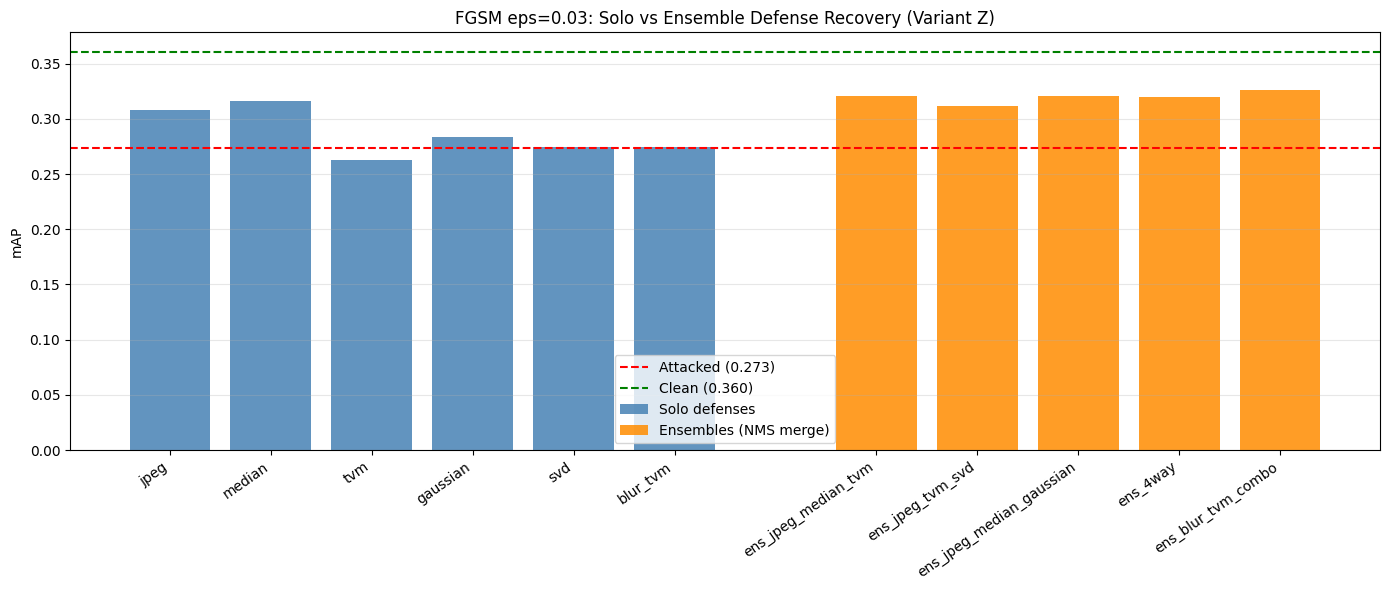

In [28]:
# Bar chart: solos vs ensembles recovery at eps=0.03
eps = EPSILONS[0]
eps_tag = f"fgsm_eps{eps}"
atk_ap = eval_stats[eps_tag][0]

solo_names = list(DEFENSES.keys())
ens_names = list(ENSEMBLES.keys())
solo_maps = [eval_stats.get(f"{eps_tag}+{d}", np.zeros(12))[0] for d in solo_names]
ens_maps  = [eval_stats.get(f"{eps_tag}+{e}", np.zeros(12))[0] for e in ens_names]

fig, ax = plt.subplots(figsize=(14, 6))
x_solo = np.arange(len(solo_names))
x_ens  = np.arange(len(ens_names)) + len(solo_names) + 1  # gap
ax.bar(x_solo, solo_maps, color='steelblue', label='Solo defenses', alpha=0.85)
ax.bar(x_ens, ens_maps, color='darkorange', label='Ensembles (NMS merge)', alpha=0.85)
ax.axhline(y=atk_ap, color='red', linestyle='--', label=f'Attacked ({atk_ap:.3f})')
ax.axhline(y=clean_ap, color='green', linestyle='--', label=f'Clean ({clean_ap:.3f})')
ax.set_xticks(list(x_solo) + list(x_ens))
ax.set_xticklabels(solo_names + ens_names, rotation=35, ha='right')
ax.set_ylabel('mAP')
ax.set_title(f'FGSM eps={eps}: Solo vs Ensemble Defense Recovery (Variant Z)')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "results_plot_variantZ.png"), dpi=150, bbox_inches='tight')
plt.show()


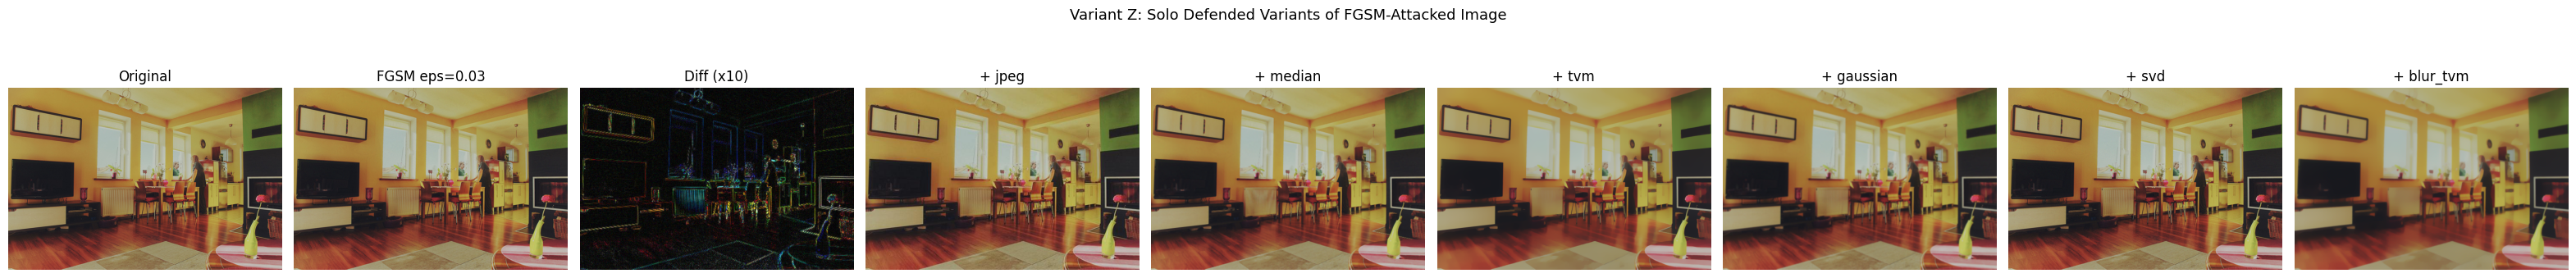

In [29]:
# Visual comparison of the 6 solo defenses on a sample FGSM-attacked image
sample_fname = files[0]
sample_img = Image.open(os.path.join(IMAGE_DIR, sample_fname)).convert("RGB")
sample_adv = fgsm_attack(sample_img, eps=0.03)
defended = apply_all_defenses_gpu(sample_adv)

ncols = 3 + len(DEFENSE_NAMES)
fig, axes = plt.subplots(1, ncols, figsize=(3.5 * ncols, 4))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(sample_adv); axes[1].set_title("FGSM eps=0.03"); axes[1].axis("off")

diff = np.abs(np.array(sample_img).astype(float) - np.array(sample_adv).astype(float))
diff = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff); axes[2].set_title("Diff (x10)"); axes[2].axis("off")

for i, dname in enumerate(DEFENSE_NAMES):
    axes[3 + i].imshow(defended[dname])
    axes[3 + i].set_title(f"+ {dname}")
    axes[3 + i].axis("off")

plt.suptitle("Variant Z: Solo Defended Variants of FGSM-Attacked Image", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "visual_comparison_variantZ.png"), dpi=150, bbox_inches='tight')
plt.show()


## 12. Net Gain Analysis

In [30]:
print("=" * 100)
print(f"{'NET GAIN ANALYSIS (VARIANT Z)':^100}")
print("=" * 100)
print("\nNet Gain = defended_mAP - max(clean+defense_mAP, attacked_mAP)")
print("Positive = defense helps vs BOTH attacked floor AND its own clean cost.\n")

for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    print(f"  FGSM eps={eps} (attacked mAP = {atk_ap:.4f}):\n")

    print("  --- SOLO DEFENSES ---")
    for dname in all_defense_names:
        def_tag = f"{eps_tag}+{dname}"
        clean_def_tag = f"clean+{dname}"
        if def_tag in eval_stats and clean_def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            clean_def_ap = eval_stats[clean_def_tag][0]
            floor = max(atk_ap, clean_def_ap)
            net_gain = def_ap - floor
            verdict = "HELPFUL" if net_gain > 0 else "NOT HELPFUL"
            print(f"    {dname:<20} defended={def_ap:.4f}  floor={floor:.4f}  "
                  f"net_gain={net_gain:+.4f}  [{verdict}]")

    print("\n  --- ENSEMBLES ---")
    for ens in ensemble_names:
        def_tag = f"{eps_tag}+{ens}"
        clean_def_tag = f"clean+{ens}"
        if def_tag in eval_stats and clean_def_tag in eval_stats:
            def_ap = eval_stats[def_tag][0]
            clean_def_ap = eval_stats[clean_def_tag][0]
            floor = max(atk_ap, clean_def_ap)
            net_gain = def_ap - floor
            verdict = "HELPFUL" if net_gain > 0 else "NOT HELPFUL"
            print(f"    {ens:<25} defended={def_ap:.4f}  floor={floor:.4f}  "
                  f"net_gain={net_gain:+.4f}  [{verdict}]")
    print()


                                   NET GAIN ANALYSIS (VARIANT Z)                                    

Net Gain = defended_mAP - max(clean+defense_mAP, attacked_mAP)
Positive = defense helps vs BOTH attacked floor AND its own clean cost.

  FGSM eps=0.03 (attacked mAP = 0.2733):

  --- SOLO DEFENSES ---
    jpeg                 defended=0.3081  floor=0.3515  net_gain=-0.0435  [NOT HELPFUL]
    median               defended=0.3160  floor=0.3505  net_gain=-0.0345  [NOT HELPFUL]
    tvm                  defended=0.2625  floor=0.2854  net_gain=-0.0229  [NOT HELPFUL]
    gaussian             defended=0.2839  floor=0.2918  net_gain=-0.0079  [NOT HELPFUL]
    svd                  defended=0.2748  floor=0.3618  net_gain=-0.0870  [NOT HELPFUL]
    blur_tvm             defended=0.2748  floor=0.2733  net_gain=+0.0015  [HELPFUL]

  --- ENSEMBLES ---
    ens_jpeg_median_tvm       defended=0.3205  floor=0.3563  net_gain=-0.0358  [NOT HELPFUL]
    ens_jpeg_tvm_svd          defended=0.3116  floor=0.356

## 13. Attacked vs Recovered — Head-to-Head Comparison

Direct comparison of every solo + ensemble defense against the FGSM attacked baseline.
Ranked by absolute recovery (`defended_mAP - attacked_mAP`). Positive = defense recovers
mAP lost to the attack; negative = defense made things worse.


                        ATTACKED vs RECOVERED mAP — HEAD-TO-HEAD (VARIANT Z)                        

  Clean baseline mAP : 0.3604
  Attacked (FGSM eps=0.03) mAP : 0.2733
  Attack damage (clean - attacked) : +0.0871

----------------------------------------------------------------------------------------------------
  Rank  Defense                      Kind        Attacked  Recovered     Δ mAP    Rec%    Verdict
----------------------------------------------------------------------------------------------------
  1     ens_blur_tvm_combo           ENSEMBLE      0.2733     0.3263   +0.0530  +60.8%   RECOVERS
  2     ens_jpeg_median_gaussian     ENSEMBLE      0.2733     0.3210   +0.0477  +54.7%   RECOVERS
  3     ens_jpeg_median_tvm          ENSEMBLE      0.2733     0.3205   +0.0472  +54.2%   RECOVERS
  4     ens_4way                     ENSEMBLE      0.2733     0.3195   +0.0462  +53.1%   RECOVERS
  5     median                       solo          0.2733     0.3160   +0.0427  +49.0%   R

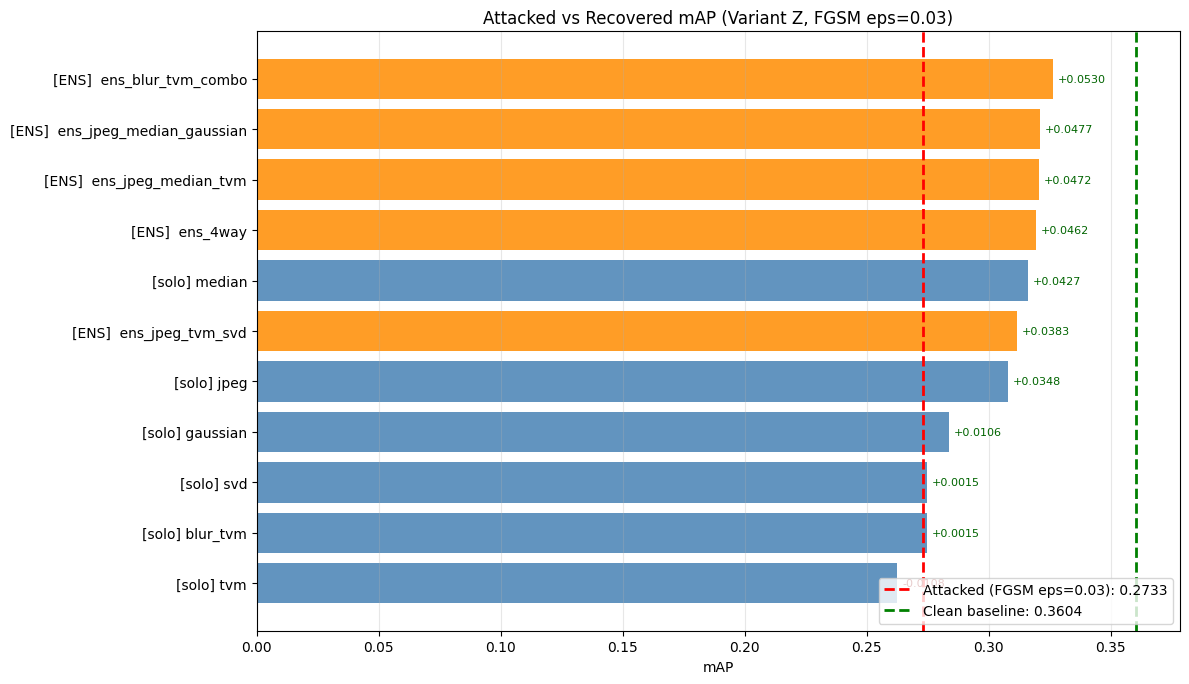


Comparison chart saved -> ./results_phase2_variantZ/attacked_vs_recovered_variantZ.png


In [31]:
print("=" * 100)
print(f"{'ATTACKED vs RECOVERED mAP — HEAD-TO-HEAD (VARIANT Z)':^100}")
print("=" * 100)

for eps in EPSILONS:
    eps_tag = f"fgsm_eps{eps}"
    atk_ap = eval_stats[eps_tag][0]
    atk_ap50 = eval_stats[eps_tag][1]
    attack_drop = clean_ap - atk_ap

    print(f"\n  Clean baseline mAP : {clean_ap:.4f}")
    print(f"  Attacked (FGSM eps={eps}) mAP : {atk_ap:.4f}")
    print(f"  Attack damage (clean - attacked) : {attack_drop:+.4f}\n")

    # Collect rows: (name, kind, defended_mAP, defended_AP50)
    rows = []
    for dname in all_defense_names:
        tag = f"{eps_tag}+{dname}"
        if tag in eval_stats:
            rows.append((dname, "solo", eval_stats[tag][0], eval_stats[tag][1]))
    for ens in ensemble_names:
        tag = f"{eps_tag}+{ens}"
        if tag in eval_stats:
            rows.append((ens, "ENSEMBLE", eval_stats[tag][0], eval_stats[tag][1]))

    # Sort by recovery (defended - attacked), descending
    rows.sort(key=lambda r: r[2] - atk_ap, reverse=True)

    # Table header
    print("-" * 100)
    print(f"  {'Rank':<5} {'Defense':<28} {'Kind':<10} {'Attacked':>9} {'Recovered':>10} "
          f"{'Δ mAP':>9} {'Rec%':>7} {'Verdict':>10}")
    print("-" * 100)

    for rank, (name, kind, def_ap, def_ap50) in enumerate(rows, 1):
        delta = def_ap - atk_ap
        rec_pct = (100.0 * delta / attack_drop) if attack_drop > 0 else 0.0
        if delta > 0.005:
            verdict = "RECOVERS"
        elif delta > 0:
            verdict = "marginal"
        elif delta > -0.005:
            verdict = "neutral"
        else:
            verdict = "HURTS"
        print(f"  {rank:<5} {name:<28} {kind:<10} {atk_ap:>9.4f} {def_ap:>10.4f} "
              f"{delta:>+9.4f} {rec_pct:>+6.1f}% {verdict:>10}")
    print("-" * 100)

    # Best recovery summary
    best = rows[0]
    worst = rows[-1]
    best_delta = best[2] - atk_ap
    best_pct = (100.0 * best_delta / attack_drop) if attack_drop > 0 else 0.0
    print(f"\n  >> BEST recovery  : {best[0]} ({best[1]})  "
          f"mAP {atk_ap:.4f} -> {best[2]:.4f}  (+{best_delta:.4f}, {best_pct:+.1f}%)")
    print(f"  >> WORST         : {worst[0]} ({worst[1]})  "
          f"mAP {atk_ap:.4f} -> {worst[2]:.4f}  ({worst[2]-atk_ap:+.4f})")

    # Solo vs ensemble aggregate — did ensembling win?
    solo_rec = [r[2] - atk_ap for r in rows if r[1] == "solo"]
    ens_rec  = [r[2] - atk_ap for r in rows if r[1] == "ENSEMBLE"]
    if solo_rec and ens_rec:
        print(f"\n  Solo     recovery  avg={np.mean(solo_rec):+.4f}  "
              f"max={max(solo_rec):+.4f}  min={min(solo_rec):+.4f}")
        print(f"  Ensemble recovery  avg={np.mean(ens_rec):+.4f}  "
              f"max={max(ens_rec):+.4f}  min={min(ens_rec):+.4f}")
        winner = "ENSEMBLING" if max(ens_rec) > max(solo_rec) else "SOLO"
        print(f"  >> Best-of-kind winner: {winner}")

# Horizontal bar chart: attacked baseline vs all recovered mAPs
fig, ax = plt.subplots(figsize=(12, 0.45 * (len(all_defense_names) + len(ensemble_names)) + 2))
eps = EPSILONS[0]
eps_tag = f"fgsm_eps{eps}"
atk_ap = eval_stats[eps_tag][0]

bar_rows = []
for dname in all_defense_names:
    tag = f"{eps_tag}+{dname}"
    if tag in eval_stats:
        bar_rows.append((f"[solo] {dname}", eval_stats[tag][0], "steelblue"))
for ens in ensemble_names:
    tag = f"{eps_tag}+{ens}"
    if tag in eval_stats:
        bar_rows.append((f"[ENS]  {ens}", eval_stats[tag][0], "darkorange"))
# sort ascending so best ends up at top
bar_rows.sort(key=lambda r: r[1])

y = np.arange(len(bar_rows))
mAPs = [r[1] for r in bar_rows]
colors = [r[2] for r in bar_rows]
ax.barh(y, mAPs, color=colors, alpha=0.85)
ax.axvline(x=atk_ap, color='red', linestyle='--', linewidth=2,
           label=f'Attacked (FGSM eps={eps}): {atk_ap:.4f}')
ax.axvline(x=clean_ap, color='green', linestyle='--', linewidth=2,
           label=f'Clean baseline: {clean_ap:.4f}')
ax.set_yticks(y)
ax.set_yticklabels([r[0] for r in bar_rows])
ax.set_xlabel('mAP')
ax.set_title(f'Attacked vs Recovered mAP (Variant Z, FGSM eps={eps})')
ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)

# Annotate each bar with delta from attacked
for yi, m in zip(y, mAPs):
    d = m - atk_ap
    col = 'darkgreen' if d > 0 else 'darkred'
    ax.text(m + 0.002, yi, f'{d:+.4f}', va='center', fontsize=8, color=col)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "attacked_vs_recovered_variantZ.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\nComparison chart saved -> {os.path.join(OUTPUT_DIR, 'attacked_vs_recovered_variantZ.png')}")


## References

**Defense Components:**
- **TVM**: Guo et al., "Countering Adversarial Images using Input Transformations," ICLR 2018 — rated "very effective"
- **JPEG**: Dziugaite et al., "A Study of the Effect of JPG Compression on Adversarial Images," 2016
- **Median Filter**: Xu et al., "Feature Squeezing: Detecting Adversarial Examples in DNNs," NDSS 2018
- **SVD Spectral**: Darabi et al., "EigenShield," arXiv:2502.14976, 2025

**Pipeline Design:**
- Guo et al., ICLR 2018 — showed stacked transforms outperform individuals; ordering matters
- Xu et al., NDSS 2018 — feature squeezing baseline

**Attack:**
- Goodfellow et al., "Explaining and Harnessing Adversarial Examples," ICLR 2015 (FGSM)